Camino encontrado: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (1, 2), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Visitados: {(2, 4), (1, 2), (0, 4), (2, 1), (3, 4), (0, 0), (0, 3), (2, 0), (1, 4), (0, 2), (2, 2), (1, 0)}


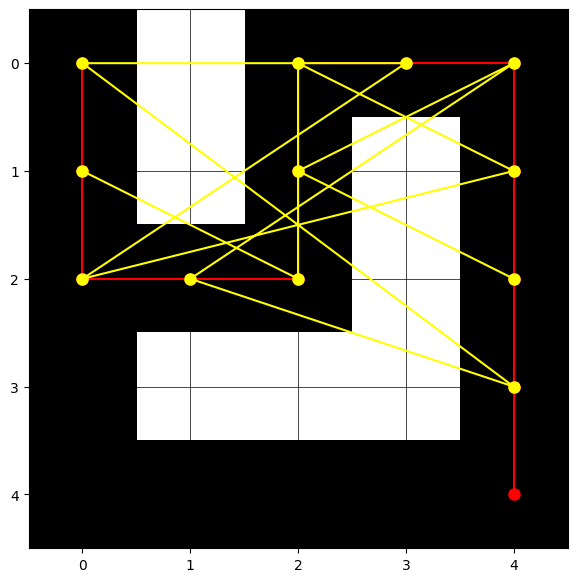

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def dfs(laberinto, x, y, visitado, camino):
    # añado la posición actual al camino
    camino.append((x, y))
    # si estoy en la salida
    if (x, y) == (len(laberinto) - 1, len(laberinto[0]) - 1):
        return True
    visitado.add((x, y))
    # busco en los 4 movimientos posibles
    MOVIMIENTOS = [
        ( 0,  1), # abajo
        ( 1,  0), # derecha
        ( 0, -1), # arriba
        (-1,  0), # izquierda
    ]
    for dx, dy in MOVIMIENTOS:
        nx, ny = x + dx, y + dy
        if 0 <= nx < len(laberinto) and 0 <= ny < len(laberinto[0]) and laberinto[nx][ny] == 1 and (nx, ny) not in visitado:
            if dfs(laberinto, nx, ny, visitado, camino):
                return True
    # si no hay camino, elimino la posición actual del camino
    camino.pop()
    return False

def resolver_laberinto(laberinto):
    camino = []
    visitado = set()
    if dfs(laberinto, 0, 0, visitado, camino):
        return camino, visitado
    return None

def dibujar_laberinto(laberinto, camino,visitado):
    filas, columnas = len(laberinto), len(laberinto[0])
    laberinto_np = np.array(laberinto)
    plt.figure(figsize=(7,7))
    plt.imshow(laberinto_np, cmap='gray_r')
    if camino:
        x, y = zip(*camino)
        plt.plot(y, x, marker='o', color='red', markersize=8, linestyle='-')
    if visitado:
        x, y = zip(*visitado)
        plt.plot(y, x, marker='o', color='yellow', markersize=8, linestyle='-')
    plt.xticks(range(columnas))
    plt.yticks(range(filas))
    plt.grid(True, which='both', linestyle='-', color='black', linewidth=0.5)
    plt.show()

laberinto = [
    [1, 0, 1, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1],
]
camino, visitado = resolver_laberinto(laberinto)
print('Camino encontrado:', camino)
print('Visitados:', visitado)
dibujar_laberinto(laberinto, camino, visitado)
